# Signal Validation: the Evidence

Backs `docs/signal_validation.md`: every column of `gld_player_signals_daily` that the features read, checked against the daily tables for brands 14, 23, 64, 72 and 73. Method in the report (section 2) and in `eda/signal_validation.py`.

`make validate-signals` (about 9 minutes) computes the checks and saves their tables; this notebook reads them and adds the evidence behind each finding. Local files only.

In [1]:
import datetime as dt
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path("..").resolve()
sys.path[:0] = [str(PROJECT_ROOT / "eda"), str(PROJECT_ROOT / "src" / "features")]
import daily_cache
import signal_snapshots
import signal_validation as sv

pd.set_option("display.width", 200)
results = sv.saved_results()
BRANDS = list(results)
LIVE = dt.date(2026, 8, 1)  # the first snapshot after the backfill of the source tables
period = lambda days: np.where(pd.to_datetime(days) < pd.Timestamp(LIVE), "until 2026-07", "from 2026-08")
recomputed = pd.concat([r["recomputed"].assign(brand=b) for b, r in results.items()], ignore_index=True)
plausible = pd.concat([r["plausible"].assign(brand=b) for b, r in results.items()], ignore_index=True)
growth = pd.concat([r["growth"].assign(brand=b) for b, r in results.items()], ignore_index=True)
print({b: f"{r['days'][0]} to {r['days'][-1]}" for b, r in results.items()})

{14: '2025-07-01 to 2026-08-01', 23: '2025-09-01 to 2026-09-01', 64: '2025-07-01 to 2026-10-01', 72: '2025-09-01 to 2026-09-01', 73: '2025-07-01 to 2026-08-01'}


## 1. Result

The checks that fail in at least one brand, and when (the report's table, without the explanations).

brand                                                                                                            14                                                 23  \
column                  check                                                                                                                                            
active_days_l30d        recomputed from the daily tables                                                         OK                                                 OK   
active_days_l7d         recomputed from the daily tables                                                         OK                                                 OK   
active_days_l90d        recomputed from the daily tables                                                         OK                                   mismatch 2025-10   
days_since_bet          recomputed from the daily tables                  mismatch 2025-07 to 2026-07; leak 2026-08  mismatch 2025-09 to 2026-07; leak 2026-08 to 2...   
deposit_frequency_score filled (not 0 for every player)                                    empty 2025-07 to 2025-12                           empty 2025-09 to 2025-12   
prior_active_days_l30d  recomputed from the daily tables                                                         OK                                                 OK   
prior_active_days_l7d   recomputed from the daily tables                                                         OK                                                 OK   
tenure_days             >= days since the first bet seen in the activity                   fails 2025-07 to 2026-07                           fails 2025-09 to 2026-07   
                        grows by the days between two snapshots                            fails 2025-08 to 2026-08                           fails 2025-10 to 2026-08   
tp_night_index          between 0 and 1 (a share of play)                                             fails 2026-08                           fails 2026-08 to 2026-09   
                        filled (not 0 for every player)                                    empty 2025-07 to 2026-07                           empty 2025-09 to 2026-07   

brand                                                                                                                    64                                                 72  \
column                  check                                                                                                                                                    
active_days_l30d        recomputed from the daily tables                                                                 OK                        mismatch 2026-07 to 2026-08   
active_days_l7d         recomputed from the daily tables                                                                 OK                                   mismatch 2026-07   
active_days_l90d        recomputed from the daily tables                                 mismatch 2026-06; mismatch 2026-08  mismatch 2026-01; mismatch 2026-05; mismatch 2...   
days_since_bet          recomputed from the daily tables                  mismatch 2025-07 to 2026-07; leak 2026-08 to 2...  mismatch 2025-09 to 2026-07; leak 2026-08 to 2...   
deposit_frequency_score filled (not 0 for every player)                                            empty 2025-07 to 2025-12                           empty 2025-09 to 2025-12   
prior_active_days_l30d  recomputed from the daily tables                                                                 OK                                   mismatch 2026-08   
prior_active_days_l7d   recomputed from the daily tables                                                                 OK                                   mismatch 2026-07   
tenure_days             >= days since the first bet seen in the activity                           fails 2025-07 to 2026-07                           fails 2025-09 to 2026-07   
         

19 of 28 columns pass every check in every brand


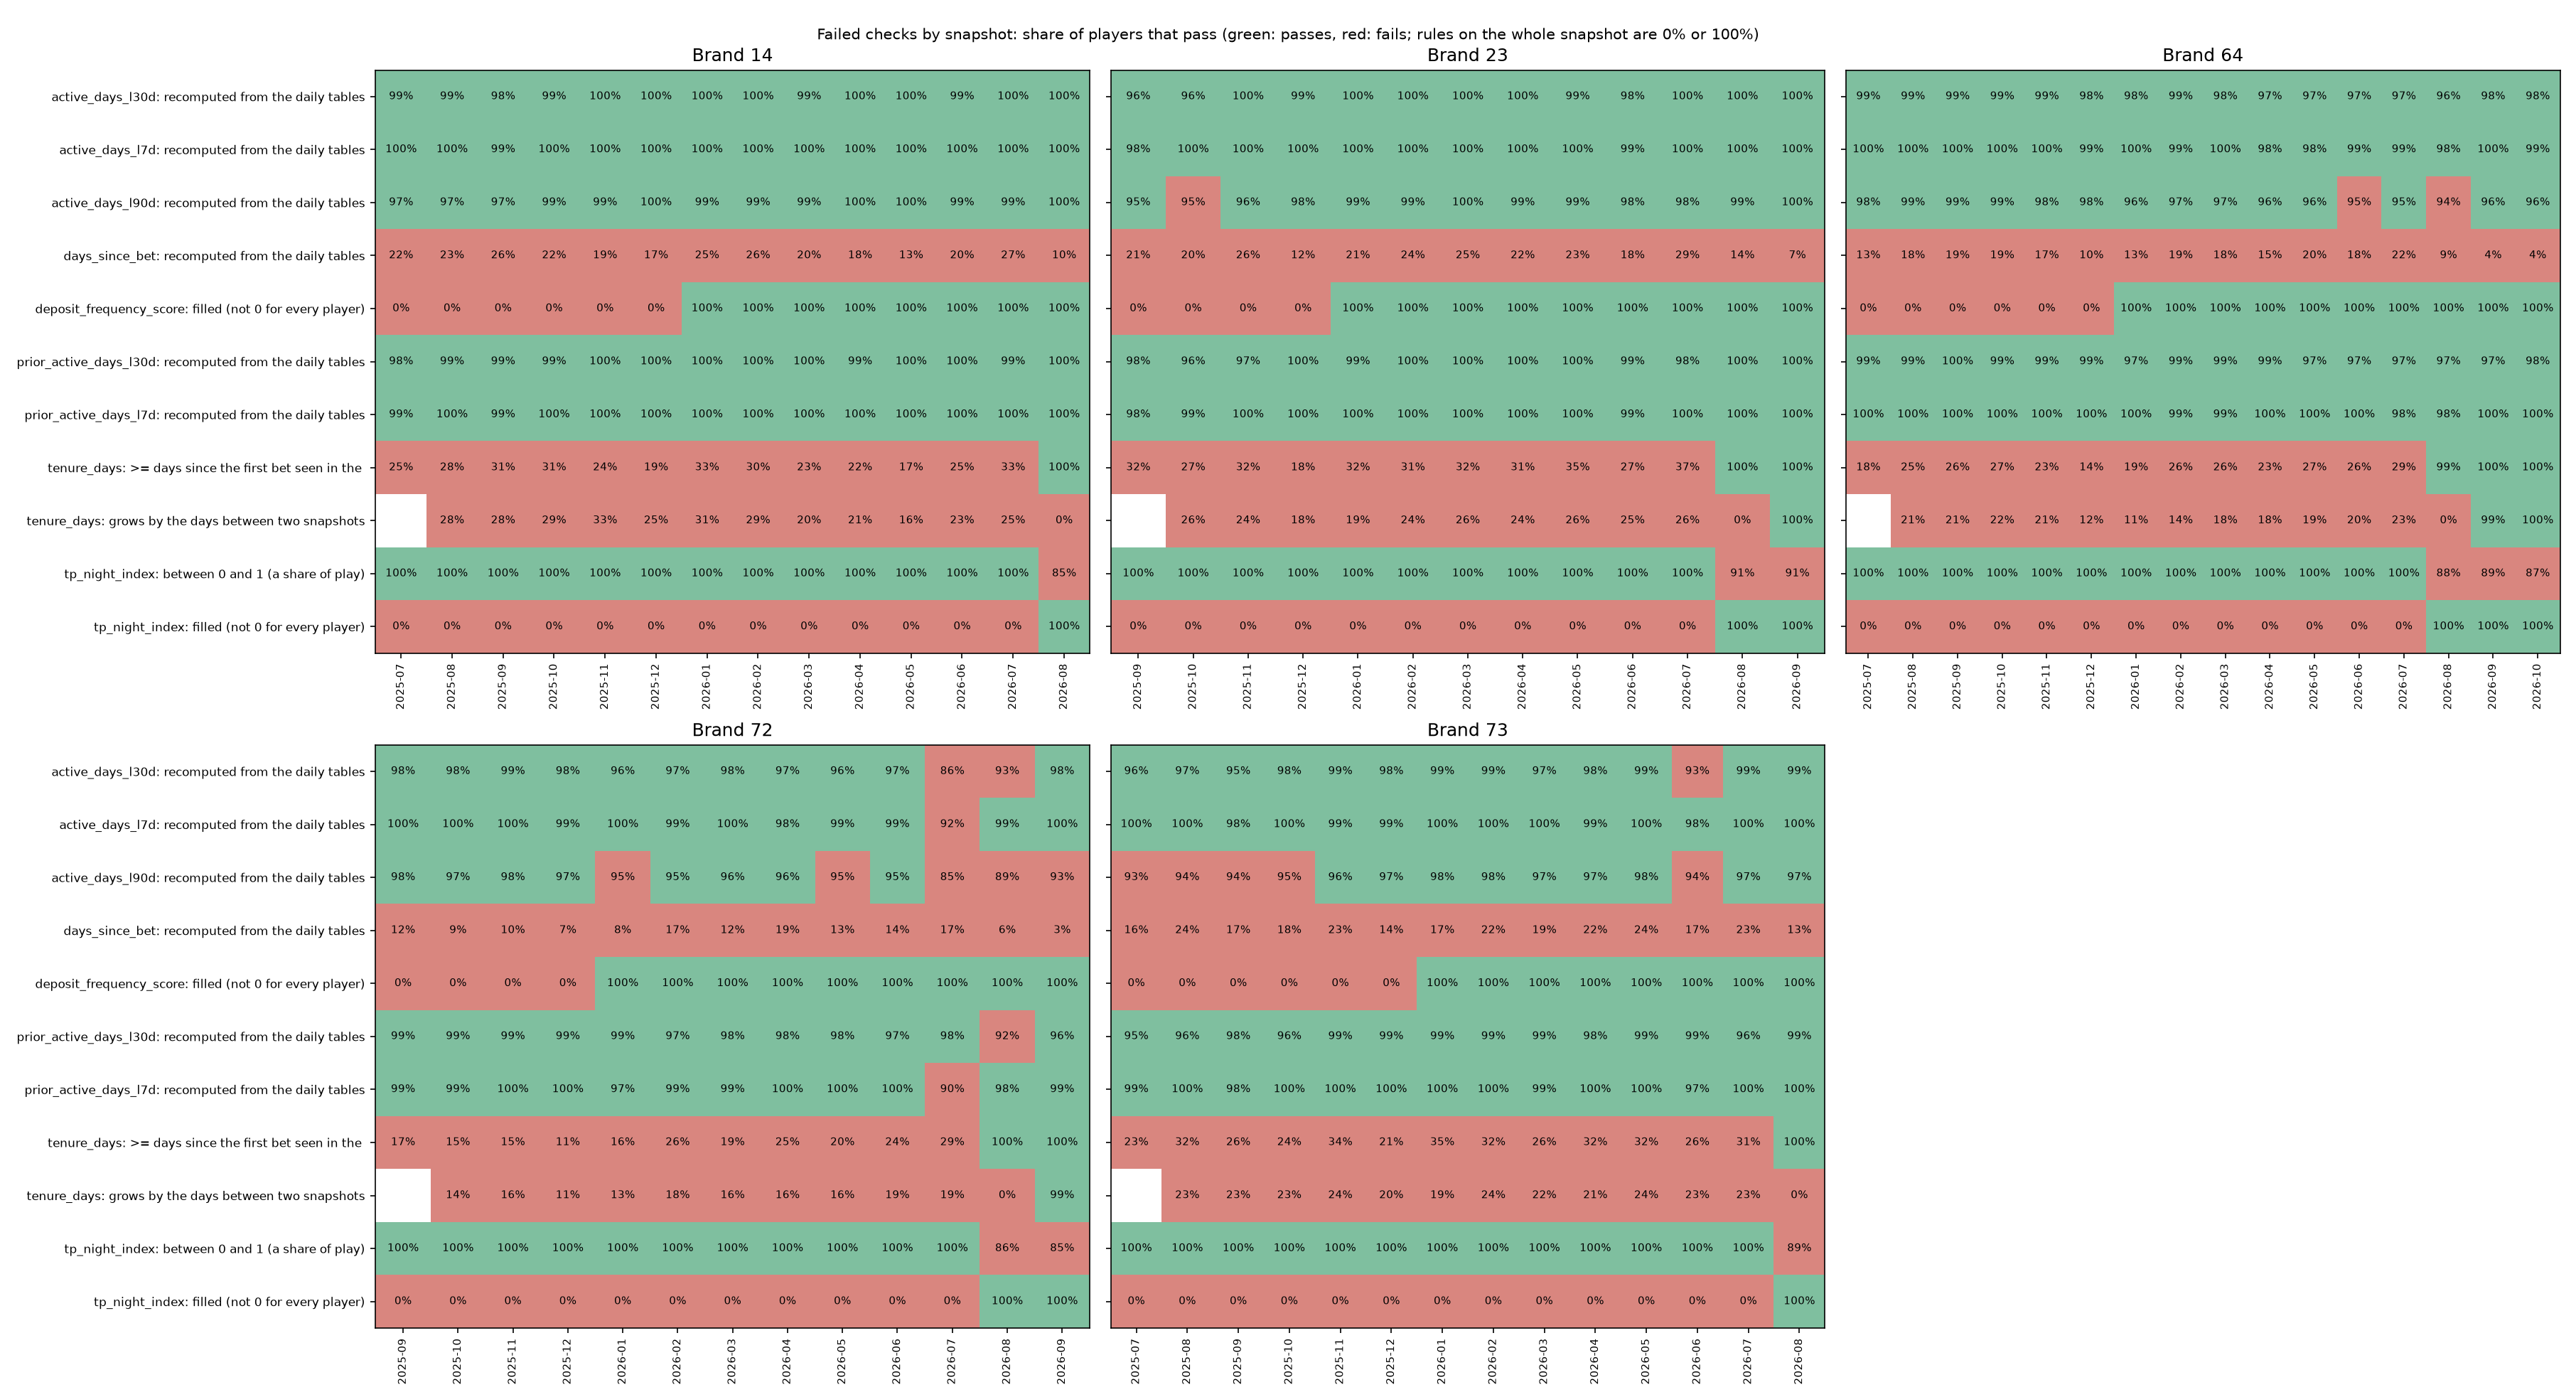

In [2]:
tables = pd.concat([r["table"].assign(brand=b) for b, r in results.items()], ignore_index=True)
failed = tables.groupby(["column", "check"])["verdict"].transform(lambda v: (v != "OK").any())
view = tables[failed].assign(result=lambda t: np.where(t["verdict"] == "OK", "OK", t["fails_on"]))
display(view.pivot(index=["column", "check"], columns="brand", values="result"))
print(f"{tables['column'].nunique() - tables.loc[failed, 'column'].nunique()} of {tables['column'].nunique()} columns pass every check in every brand")
display(Image(sv.SUMMARY_DIR / "failed_checks.png"))

## 2. `days_since_bet`: Empty, Then Built with Later Data

Median over the snapshots of each period: the share of players with 0, matching the recency as of the date, and matching the recency 7 days later. Until July 2026 it is 0 for almost everyone; from August 2026 it equals the recency of a week later.

table_zero                      match               match_7d_ahead              
period from 2026-08 until 2026-07 from 2026-08 until 2026-07   from 2026-08 until 2026-07
brand                                                                                    
14             0.14           1.0         0.10          0.22           0.98          0.10
23             0.13           1.0         0.11          0.22           0.89          0.20
64             0.02           1.0         0.04          0.18           0.92          0.16
72             0.05           1.0         0.05          0.12           0.94          0.09
73             0.19           1.0         0.13          0.19           0.98          0.14

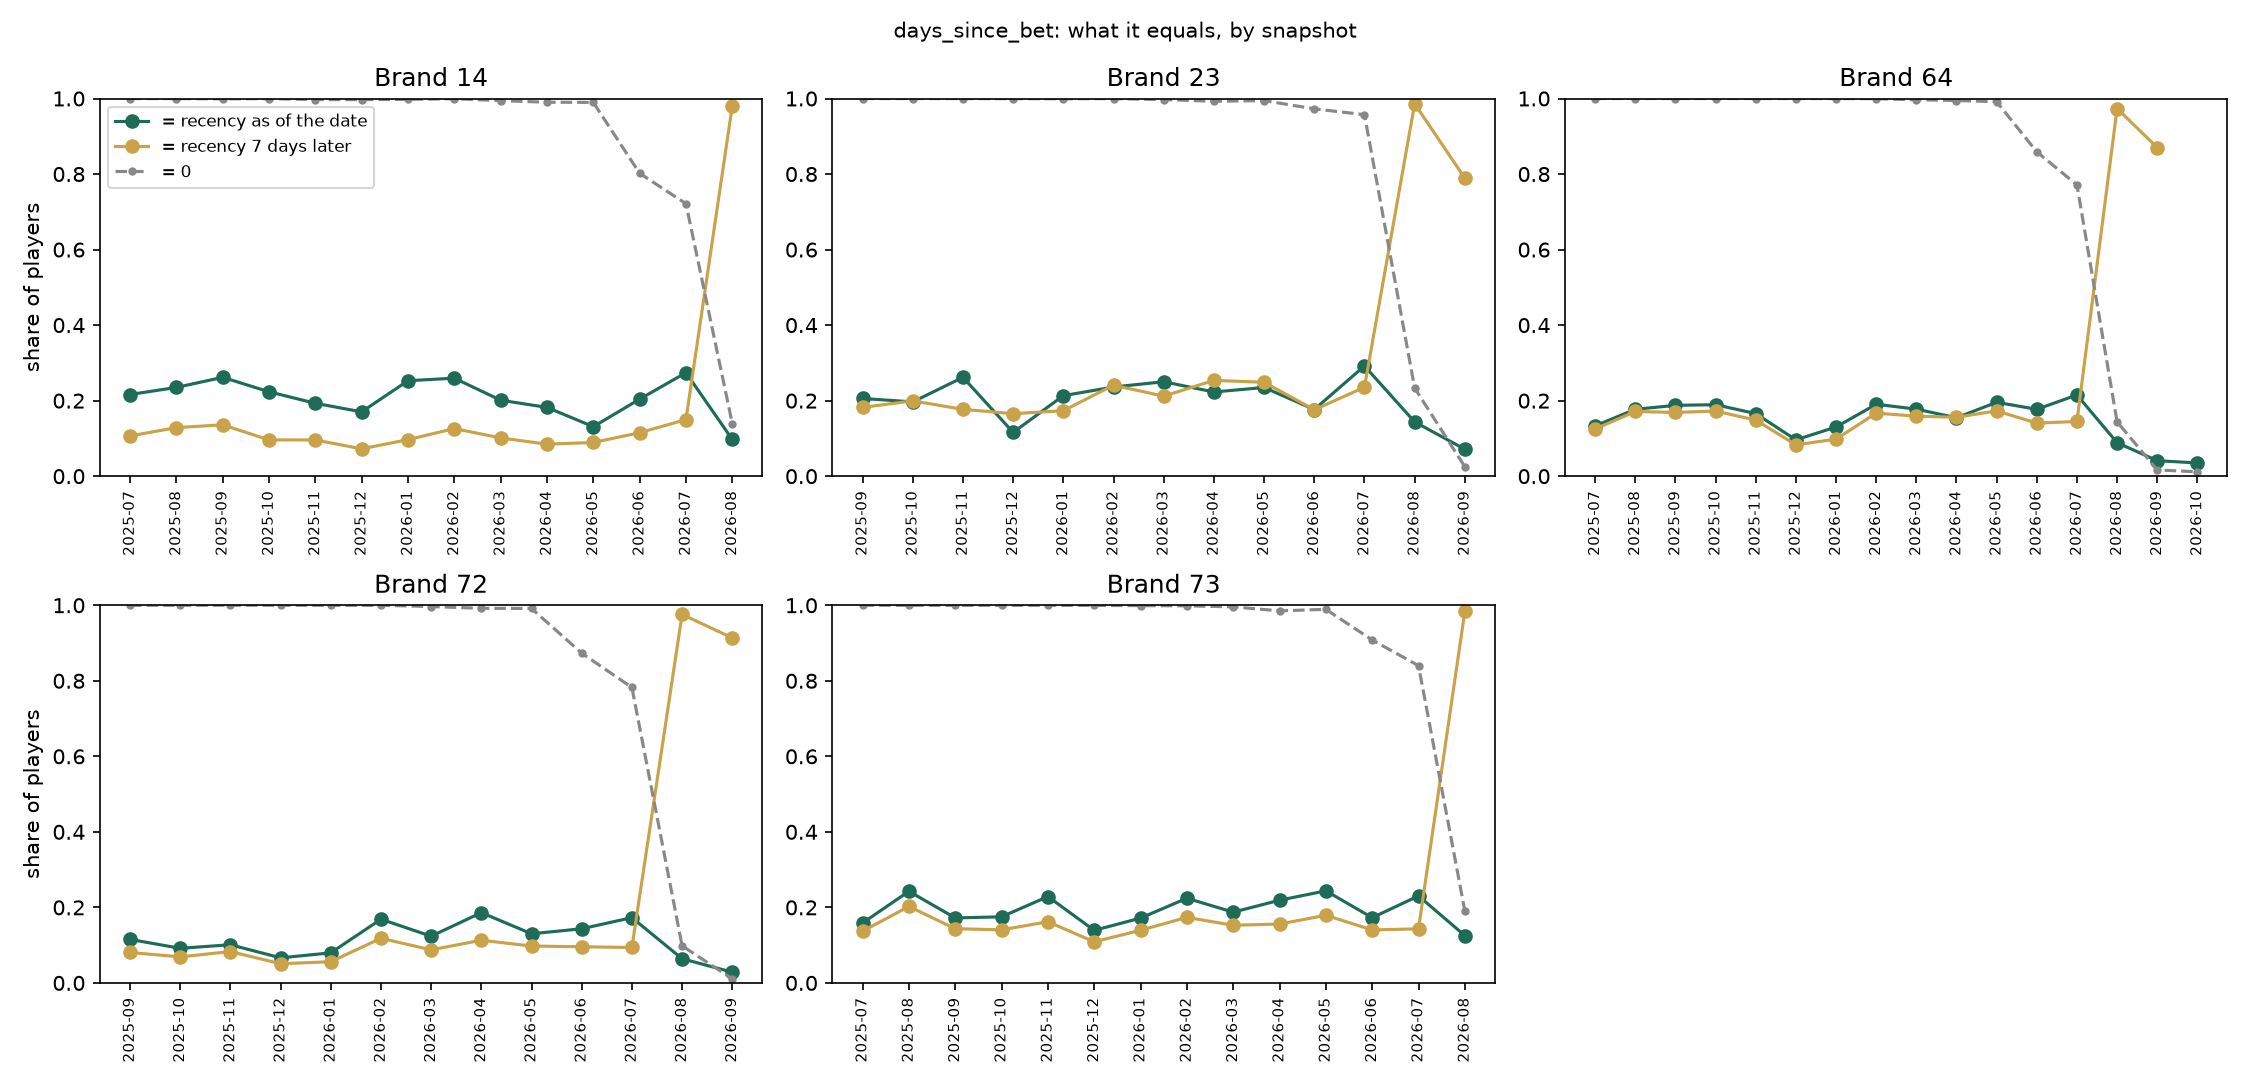

In [3]:
d = recomputed[recomputed["column"] == "days_since_bet"].assign(period=lambda x: period(x["day"]))
display(d.groupby(["brand", "period"])[["table_zero", "match", "match_7d_ahead"]].median().unstack("period").round(2))
display(Image(sv.SUMMARY_DIR / "days_since_bet_by_brand.png"))

## 3. `tenure_days`: Wrong in the Backfilled History

Median share of players for which each rule holds: tenure at least the days since the first bet seen, and tenure growing by the days between two snapshots. Both fail until July 2026; on 2026-08-01 the column is switched (it jumps, so growth fails that month) and from September both hold (brands 23, 64 and 72 have snapshots that late).

In [4]:
t = plausible[(plausible["column"] == "tenure_days")].assign(rule=">= days since the first bet")
g = growth.assign(rule="grows by the days in between", holds=growth["share_growing_as_expected"])
both = pd.concat([t, g], ignore_index=True)
day = pd.to_datetime(both["day"])
both["period"] = np.select([day < "2026-08-01", day == "2026-08-01"], ["until 2026-07", "2026-08 (switch)"], "from 2026-09")
both.groupby(["brand", "rule", "period"])["holds"].median().unstack("period")[["until 2026-07", "2026-08 (switch)", "from 2026-09"]].round(2)

period                              until 2026-07  2026-08 (switch)  from 2026-09
brand rule                                                                       
14    >= days since the first bet            0.25              1.00           NaN
      grows by the days in between           0.27              0.00           NaN
23    >= days since the first bet            0.32              1.00          1.00
      grows by the days in between           0.24              0.00          1.00
64    >= days since the first bet            0.26              0.99          1.00
      grows by the days in between           0.19              0.00          0.99
72    >= days since the first bet            0.19              1.00          1.00
      grows by the days in between           0.16              0.00          0.99
73    >= days since the first bet            0.31              1.00           NaN
      grows by the days in between           0.23              0.00           NaN

## 4. Active Days: Higher Than the Bet Days, Never Lower

For the active-day columns: the worst match over the snapshots, and among the players that do not match, the largest share where the table is higher and where it is lower. A one-sided difference is a different definition, not noise.

In [5]:
a = recomputed[recomputed["column"].str.contains("active_days")]
display(a.groupby(["column", "brand"])[["match", "table_higher", "table_lower"]]
         .agg({"match": "min", "table_higher": "max", "table_lower": "max"}).unstack("brand").round(3))
print(f"largest share where the table is lower, any brand, column and snapshot: {a['table_lower'].max():.3f}")

match                             table_higher                             table_lower                      
brand                      14     23     64     72     73           14     23     64     72     73          14   23   64   72     73
column                                                                                                                              
active_days_l30d        0.978  0.957  0.956  0.859  0.934        0.022  0.043  0.044  0.141  0.066       0.000  0.0  0.0  0.0  0.000
active_days_l7d         0.989  0.981  0.981  0.925  0.977        0.011  0.019  0.019  0.075  0.023       0.000  0.0  0.0  0.0  0.000
active_days_l90d        0.972  0.946  0.943  0.848  0.929        0.028  0.054  0.057  0.152  0.071       0.000  0.0  0.0  0.0  0.000
prior_active_days_l30d  0.977  0.963  0.971  0.920  0.955        0.023  0.037  0.029  0.080  0.045       0.000  0.0  0.0  0.0  0.000
prior_active_days_l7d   0.990  0.983  0.981  0.902  0.971        0.010  0.017  0.019  0.098  0.028       0.001  0.0  0.0  0.0  0.001

largest share where the table is lower, any brand, column and snapshot: 0.001


Brand 72 is the largest case (July 2026). Two explanations ruled out: our activity cache has no gap around those dates, and adding the days with a payment does not reproduce the table (fewer players match, not more).

In [6]:
brand, day = 72, dt.date(2026, 7, 1)
data = sv.load(brand)
ts = pd.Timestamp(day)
act = data["activity"]
per_day = act[(act["day"] > ts - pd.Timedelta(60, unit="D")) & (act["day"] <= ts + pd.Timedelta(31, unit="D"))].groupby("day").size()
gaps = pd.date_range(per_day.index.min(), per_day.index.max()).difference(per_day.index)
print(f"brand {brand}, {per_day.index.min().date()} to {per_day.index.max().date()}: {len(gaps)} days with no activity rows; "
      f"fewest rows in a day {per_day.min():,}")
pop = act[(act["day"] > ts - pd.Timedelta(30, unit="D")) & (act["day"] <= ts)][sv.KEY].drop_duplicates()
snap = signal_snapshots.snapshots([day], brand, build_missing=False).merge(pop, on=sv.KEY).set_index(sv.KEY)
window = lambda f: f[(f["day"] > ts - pd.Timedelta(30, unit="D")) & (f["day"] <= ts)][sv.KEY + ["day"]].drop_duplicates()
count = lambda f: f.groupby(sv.KEY)["day"].nunique().reindex(snap.index).fillna(0)
table = snap["active_days_l30d"].astype(float)
bets, payments = window(act), window(data["payments"])
for name, mine in (("bet days", count(bets)), ("bet or payment days", count(pd.concat([bets, payments]).drop_duplicates()))):
    print(f"active_days_l30d on {day} equals the {name} for {np.isclose(table, mine, atol=0.5).mean():.1%} of the players")

brand 72, 2026-05-03 to 2026-08-01: 0 days with no activity rows; fewest rows in a day 1,424
active_days_l30d on 2026-07-01 equals the bet days for 85.9% of the players
active_days_l30d on 2026-07-01 equals the bet or payment days for 63.2% of the players


## 5. `tp_night_index` and `deposit_frequency_score`: Not Filled Early On

`tp_night_index` is 0 for every player until July 2026 and, once filled, goes above 1, so it is not a share of play. `deposit_frequency_score` is 0 for every player before 2026, like the payments table, which has almost no deposits before then.

In [7]:
rows = []
for b in BRANDS:
    night = signal_snapshots.snapshots([d for d in results[b]["days"] if d >= LIVE], b, build_missing=False)["tp_night_index"].astype(float)
    pay = daily_cache.read("payments", b)
    month = pd.to_datetime(pay["day"]).dt.to_period("M")
    deposits = pay[pay["deposit_count"] > 0].groupby(month[pay["deposit_count"] > 0]).size()
    rows.append({"brand": b, "tp_night_index max": round(night.max(), 2), "tp_night_index above 1": f"{(night > 1).mean():.1%}",
                 "deposit rows per month, 2025": round(deposits[deposits.index.year == 2025].mean()),
                 "deposit rows per month, 2026": round(deposits[deposits.index.year == 2026].mean())})
pd.DataFrame(rows).set_index("brand")

,tp_night_index max,tp_night_index above 1,"deposit rows per month, 2025","deposit rows per month, 2026"
brand,,,,
14,4.0,15.0%,298,24922
23,4.0,8.7%,485,94976
64,4.0,11.7%,209,35794
72,4.0,14.1%,199,30318
73,4.0,10.8%,252,78612


## 6. The Later-Data Tests Can See a Leak

Positive controls on brand 64: honest columns and the same columns counted 3 or 7 days later. Both tests pass the honest ones and fail the leaked ones.

In [8]:
brand, data = 64, sv.load(64)
act = data["activity"]
day = max(d for d in results[brand]["days"] if pd.Timestamp(d) + pd.Timedelta(sv.PROFILE_AHEAD, unit="D") <= act["day"].max())
ts = pd.Timestamp(day)
players = pd.MultiIndex.from_frame(act[(act["day"] > ts - pd.Timedelta(30, unit="D")) & (act["day"] <= ts)][sv.KEY].drop_duplicates())


def profile(x):
    ranks = x.rank().to_numpy()
    bet_on = lambda o: players.isin(pd.MultiIndex.from_frame(act[act["day"] == ts + pd.Timedelta(o, unit="D")][sv.KEY]))
    return pd.Series({o: np.corrcoef(ranks, bet_on(o).astype(float))[0, 1] for o in range(1 - sv.PROFILE_BEFORE, sv.PROFILE_AHEAD + 1)})


def bet_days(shift):
    end = ts + pd.Timedelta(shift, unit="D")
    return act[(act["day"] > end - pd.Timedelta(30, unit="D")) & (act["day"] <= end)].groupby(sv.KEY)["day"].nunique().reindex(players).fillna(0)


rows = []
for shift in (0, 3, 7):
    built = "honest" if shift == 0 else f"{shift} days later"
    end = sv.window_end(profile(sv._recompute(data, "active_days_l7d", ts, shift).reindex(players).fillna(0)))
    rows.append({"column": "active_days_l7d", "built": built, "test": "7-day: window end", "value": end, "passes": end <= sv.EDGE_SLACK})
    bets30 = sv._recompute(data, "bets_l30d", ts, shift).reindex(players).fillna(0)
    gap = bets30.corr(bet_days(0), method="spearman") - bets30.corr(bet_days(sv.SHIFT_DAYS), method="spearman")
    rows.append({"column": "bets_l30d", "built": built, "test": "30-day: own minus later", "value": round(gap, 3), "passes": gap >= 0})
print(f"brand {brand}, snapshot {day}")
pd.DataFrame(rows)

brand 64, snapshot 2026-09-01


,column,built,test,value,passes
0,active_days_l7d,honest,7-day: window end,0.000,True
1,bets_l30d,honest,30-day: own minus later,0.059,True
2,active_days_l7d,3 days later,7-day: window end,3.000,False
3,bets_l30d,3 days later,30-day: own minus later,-0.006,False
4,active_days_l7d,7 days later,7-day: window end,7.000,False
5,bets_l30d,7 days later,30-day: own minus later,-0.112,False


## 7. Conclusions

- 19 of 28 columns pass every check in the five brands: the window sums and counts the features read are correct.
- `days_since_bet` is unusable (0 until July 2026, a week of later data after that) and `tenure_days` is wrong in the backfilled history: the pipeline recomputes both from the daily activity.
- The active-day columns count some days with no bet, in every brand, never fewer; not a gap in our data nor the payment days. A definition to confirm with the data team: two of them are model inputs.
- `tp_night_index` is not a share and only exists from August 2026; `deposit_frequency_score` is empty before 2026, like the payments data. Neither is in a model.
- The later-data tests catch leaks of 3 and 7 days built on purpose, so the columns they pass were not built with later data.